In [1]:
import ratinabox
from ratinabox.Agent import Agent
from ratinabox.Neurons import PlaceCells
from ratinabox.contribs.NeuralNetworkNeurons import NeuralNetworkNeurons #for the Actor and Critic
from ratinabox.contribs.TaskEnvironment import (SpatialGoalEnvironment, SpatialGoal, Reward)

#misc
import torch 
import numpy as np 
from gymnasium.spaces import Box
from tqdm import tqdm
import time
import random

from plotting_utils import *
from base_actor_critic import *
from training_utils import *

In [2]:
#TASK CONSTANTS
DT = 0.1 # Time step
T_TIMEOUT = 15 # Time out
GOAL_POS = np.array([0.5, 0.5]) # Goal position
WALL = None
GOAL_RADIUS = 0.1
REWARD = 1 # Reward
REWARD_DURATION = 1 # Reward duration

#LEARNING CONSTANTS
TAU = 5 # Discount time horizon
TAU_E = 5 # Eligibility trace time horizon
ETA = 0.01 # Learning rate 
N_EPISODES = 5000 # Number of episodes
L2 = 0.000 # L2 regularization

    • To AUTOMATICALLY save all plots (recommended), set  `ratinabox.autosave_plots = True`
    • To MANUALLY save plots, call                        `ratinabox.utils.save_figure(figure_object, save_title).
      This warning will not be shown again
HINT: You can stylize plots to make them look like repo/paper by calling `ratinabox.stylize_plots()`
      This hint will not be shown again


Text(0.5, 1.0, 'Vy')

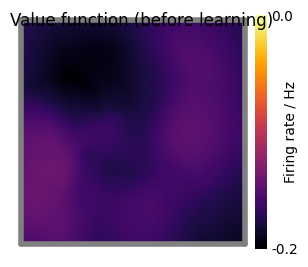

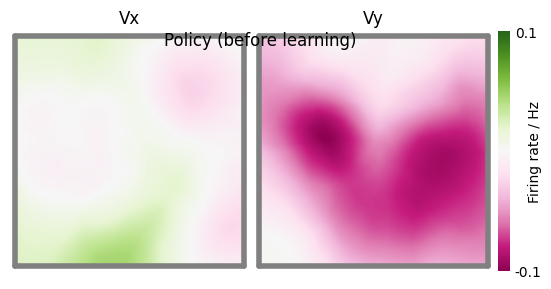

In [3]:
# MLP for the Actor and Critic

# Make the environment, egent and place cells 
env, ag = generate_navigation_task_env()
placecells = PlaceCells(ag, params={'n':50,}) 

#Make the actor and the critic (first make their core NNs then pass these to the full Actor and Critic classes)
actorNN  = VxVyGaussianMLP(n_in=placecells.n)
criticNN = MultiLayerPerceptron(n_in=placecells.n)
#
actor  = Actor(ag, params = {'input_layers':[placecells], 'NeuralNetworkModule':actorNN}); actor.colormap="PiYG"
critic = Critic(ag, params = {'input_layers':[placecells], 'NeuralNetworkModule':criticNN})

#This visualises the value function and "policy" over the entire environment
fig, ax = critic.plot_rate_map(); fig.suptitle("Value function (before learning)")
fig, ax = actor.plot_rate_map(zero_center=True); fig.suptitle("Policy (before learning)"); ax[0].set_title("Vx"); ax[1].set_title("Vy")

In [6]:
train_agent_episodes(env, ag, actor, critic, placecells, n_episodes=N_EPISODES)

<success fraction>: 1.00, <episode time>: 4.7:  42%|████▏     | 2113/5000 [30:54<42:14,  1.14it/s]     


(<Figure size 250x250 with 1 Axes>, <Axes: >)

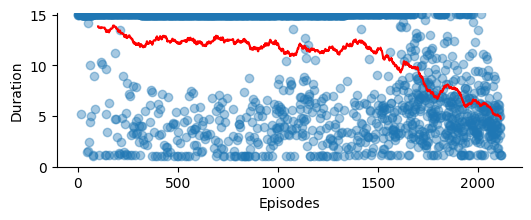

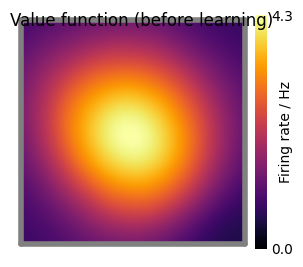

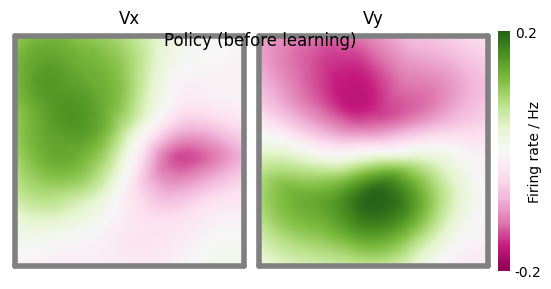

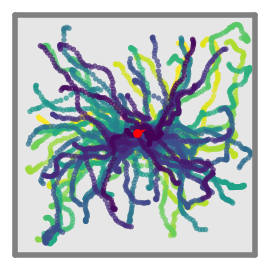

In [7]:
#This plots the reward history over training
fig, ax = plot_reward_history(env)
#This visualises the value function and "policy" over the entire environment
fig, ax = critic.plot_rate_map(); fig.suptitle("Value function (before learning)")
fig, ax = actor.plot_rate_map(zero_center=True); fig.suptitle("Policy (before learning)"); ax[0].set_title("Vx"); ax[1].set_title("Vy")
#Shows the trajectory of the agent over the last 100 episodes
fig, ax = ag.plot_trajectory(color="changing",t_start=env.episodes['start'][-100],t_end=env.episodes['start'][-1],); display_reward_patch(fig,ax)

 fta_eta: 0.2, n_tilings: 1, n_tiles: 10


Text(0.5, 1.0, 'Vy')

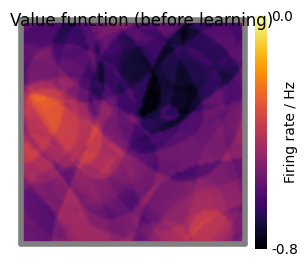

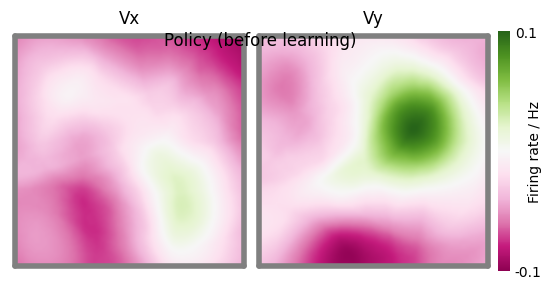

In [5]:
env_fta, ag_fta = generate_navigation_task_env()
placecells_fta = PlaceCells(ag_fta, params={'n':50,}) 
# env.render(render_mode='matplotlib')
actorNN_fta  = VxVyGaussianMLP(n_in=placecells_fta.n)
criticNN_fta = FTANetwork(n_in=placecells_fta.n,post_fta=[1])
#
actor_fta  = Actor(ag_fta, params = {'input_layers':[placecells_fta], 'NeuralNetworkModule':actorNN_fta}); actor_fta.colormap="PiYG"
critic_fta = Critic(ag_fta, params = {'input_layers':[placecells_fta], 'NeuralNetworkModule':criticNN_fta})
fig, ax = critic_fta.plot_rate_map(); fig.suptitle("Value function (before learning)")
fig, ax = actor_fta.plot_rate_map(zero_center=True); fig.suptitle("Policy (before learning)"); ax[0].set_title("Vx"); ax[1].set_title("Vy")


In [9]:
train_agent_episodes(env_fta, ag_fta, actor_fta, critic_fta, placecells_fta, n_episodes=N_EPISODES)

<success fraction>: 0.95, <episode time>: 5.7: 100%|██████████| 5000/5000 [22:00<00:00,  3.79it/s]    


(<Figure size 250x250 with 1 Axes>, <Axes: >)

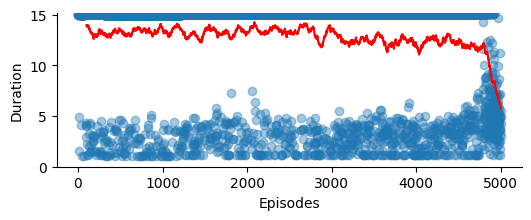

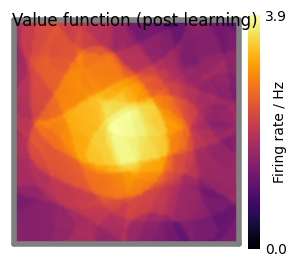

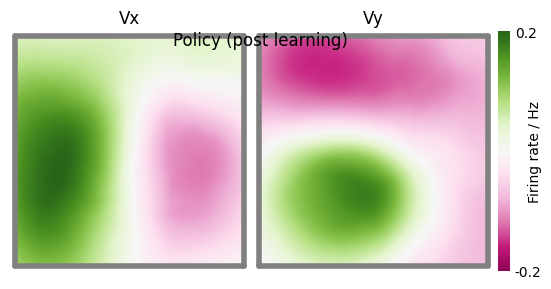

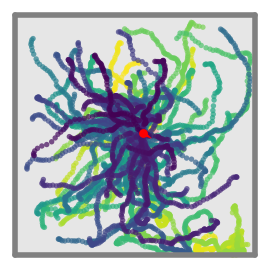

In [10]:
#This plots the reqard history over training
fig, ax = plot_reward_history(env_fta)
#This visualises the value function and "policy" over the entire environment
fig, ax = critic_fta.plot_rate_map(); fig.suptitle("Value function (post learning)")
fig, ax = actor_fta.plot_rate_map(zero_center=True); fig.suptitle("Policy (post learning)"); ax[0].set_title("Vx"); ax[1].set_title("Vy")
#Shows the trajectory of the agent over the last 100 episodes
fig, ax = ag_fta.plot_trajectory(color="changing",t_start=env_fta.episodes['start'][-100],t_end=env_fta.episodes['start'][-1],); display_reward_patch(fig,ax)
